# Overview

A brain tumor is an abnormal growth of cells within the brain. Due to the rigid structure of the skull, any abnormal growth can increase intracranial pressure and potentially lead to severe neurological damage. Early detection and accurate classification of brain tumors are critical for selecting appropriate treatment strategies and improving patient outcomes.

In this project, we develop a deep learning-based computer vision model to automatically classify brain MRI images into clinically relevant categories. Automating this process can assist radiologists by providing faster and more consistent preliminary assessments.

<img src="https://cdn-images-1.medium.com/v2/resize:fit:800/1*f1sodi17fNcObGBmIKgGGQ.gif" width=400>

The dataset consists of 7,200 human brain MRI images categorized into four classes:

- **Glioma** – tumors arising from glial cells, often aggressive
- **Meningioma** – tumors originating in the meninges, typically slower growing
- **Pituitary** – tumors affecting the pituitary gland
- **No tumor** – healthy brain scans

### Dataset Structure
```
Training/
    glioma/        (1400 images)
    meningioma/    (1400 images)
    pituitary/     (1400 images)
    notumor/       (1400 images)

Testing/
    glioma/        (400 images)
    meningioma/    (400 images)
    pituitary/     (400 images)
    notumor/       (400 images)
```

### Approach
- Data preprocessing and augmentation to improve generalization
- Transfer learning using a pretrained CNN backbone (Xception)
- Fine-tuning with class balancing and regularization
- Evaluation using accuracy, precision, recall, and confusion matrix

# 1. Import Libraries

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=all, 1=info, 2=warning, 3=error only
import random
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import shutil
from sklearn.model_selection import train_test_split

In [2]:
!pip install --upgrade tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 23.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: h5py
    Found existing installation: h5py 3.15.1
    Uninstalling h5py-3.15.1:
      Successfully uninstalled h5py-3.15.1
  Attempting uninstall: keras
    Found existing installation: keras 3.10.0
    Uninstalling keras-3.10.0:
      Successfully uninstalled keras-3.10.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency resolver does not currently t

In [3]:
import tensorflow as tf
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

# 2. Exploratory Data Analysis

In [4]:
data_dir = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"
train_dir = data_dir + "/Training"
test_dir = data_dir + "/Testing"

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
class_names

['glioma', 'meningioma', 'notumor', 'pituitary']

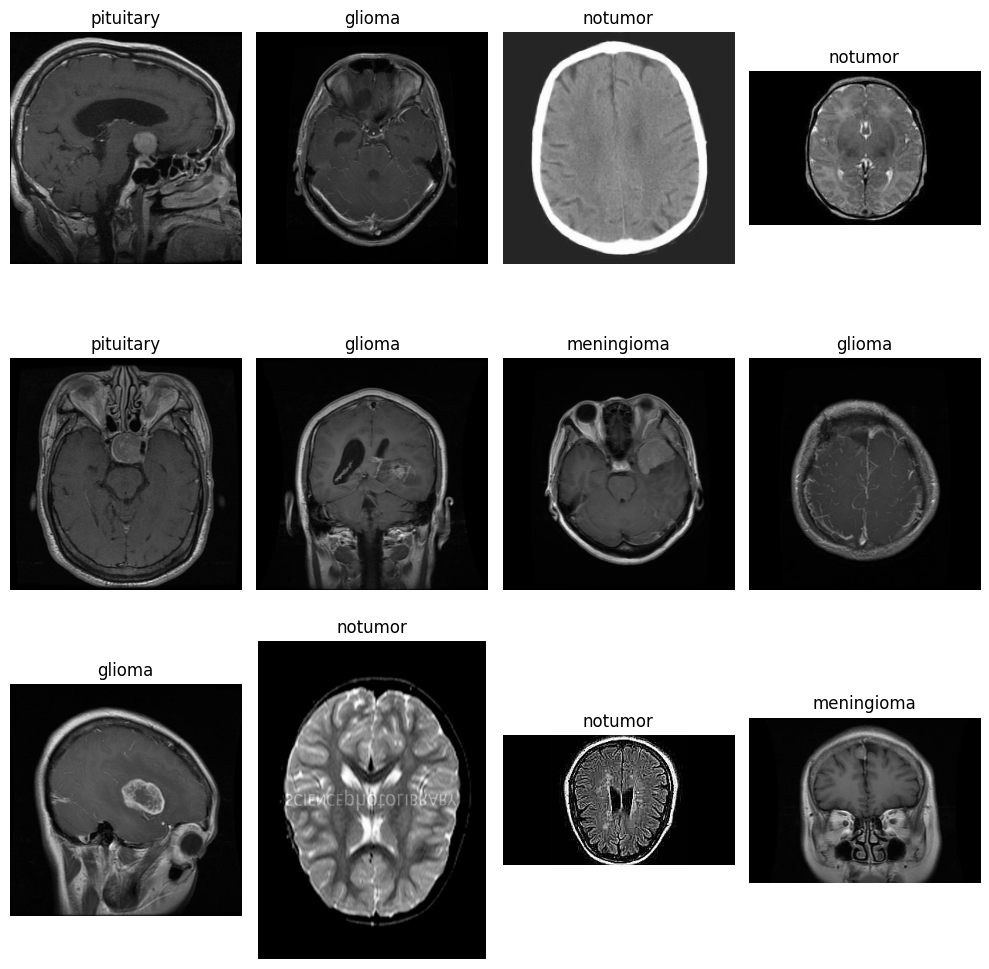

In [5]:
plt.figure(figsize=(10, 10))

for i in range(12):
    class_name = random.choice(class_names)
    img_path = os.path.join(train_dir, class_name, random.choice(os.listdir(os.path.join(train_dir, class_name))))
    img = cv2.imread(img_path)

    plt.subplot(3, 4, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")
    
plt.tight_layout()
plt.show()

## 2.1 Class Distribution

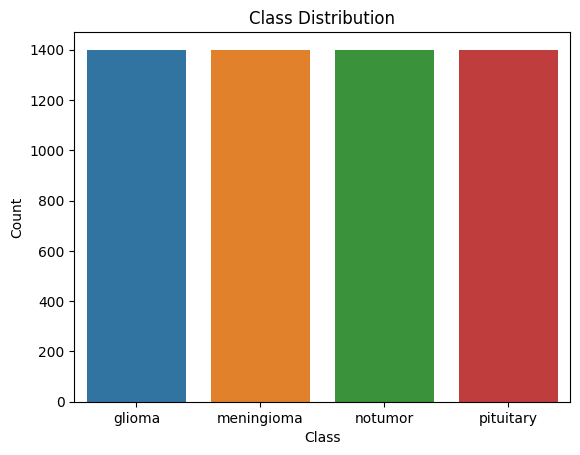

In [6]:
class_count = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    count = len(os.listdir(class_path))
    class_count.append((class_name, count))

class_df = pd.DataFrame(class_count, columns=["Class", "Count"])

sns.barplot(data=class_df, x="Class", y="Count", hue="Class")
plt.title("Class Distribution")
plt.show()

## 2.2 Image Sizes Range

In [7]:
widths = []
heights = []
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    for img_name in os.listdir(class_path)[:100]:
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        h, w, _ = img.shape
        widths.append(w) if w not in widths else None
        heights.append(h) if h not in heights else None

print("Width Range:", min(widths), "to", max(widths))
print("Height Range:", min(heights), "to", max(heights))

Width Range: 150 to 1000
Height Range: 192 to 993


## 2.3 Classwise Pixel Intensity Distribution

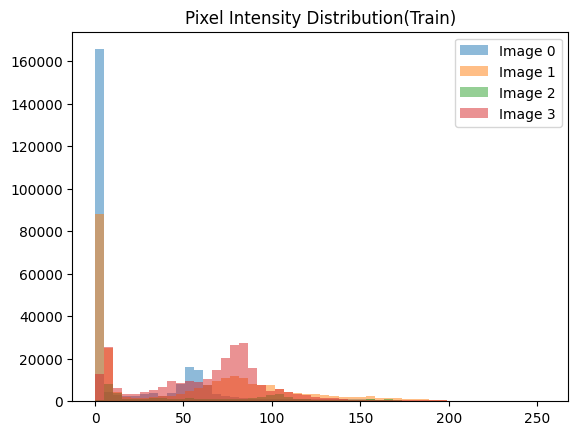

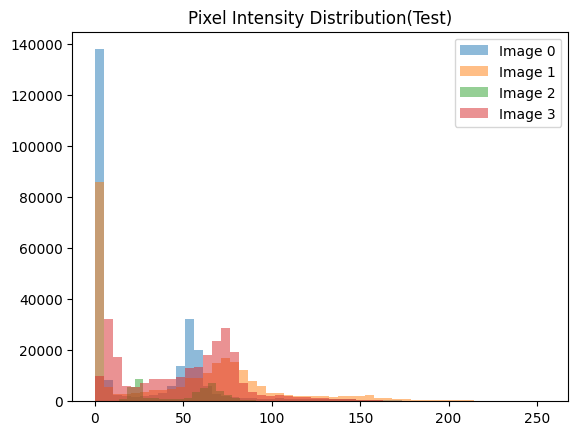

In [8]:
sample_images_train = []
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    img_name = random.choice(os.listdir(class_path))
    img = cv2.imread(os.path.join(class_path, img_name), cv2.IMREAD_GRAYSCALE)
    sample_images_train.append(img)

for i, image in enumerate(sample_images_train):
    plt.hist(image.ravel(), bins=50, alpha=0.5, label=f"Image {i}")

plt.legend()
plt.title("Pixel Intensity Distribution(Train)")
plt.show()

sample_images_test = []
for class_name in class_names:
    class_path = os.path.join(test_dir, class_name)
    img_name = random.choice(os.listdir(class_path))
    img = cv2.imread(os.path.join(class_path, img_name), cv2.IMREAD_GRAYSCALE)
    sample_images_test.append(img)

for i, image in enumerate(sample_images_test):
    plt.hist(image.ravel(), bins=50, alpha=0.5, label=f"Image {i}")

plt.legend()
plt.title("Pixel Intensity Distribution(Test)")
plt.show()

We need normalization, because:
- Data is heavily skewed toward dark values.
- Different images have different distributions.

# 3. Load the Dataset

In [9]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

tf.debugging.set_log_device_placement(False)

> Shuffle all images and then make the split, perhaps there is a data mismatch between the training and testing images


In [10]:
def move_data_to_work(train_dir, test_dir, train_out, test_out, test_size=0.15):
    filepaths = []
    labels = []

    # Collect all data from both directories
    for base_dir in [train_dir, test_dir]:
        for class_name in os.listdir(base_dir):
            class_path = os.path.join(base_dir, class_name)

            if not os.path.isdir(class_path):
                continue

            for fname in os.listdir(class_path):
                fpath = os.path.join(class_path, fname)

                if os.path.isfile(fpath):
                    filepaths.append(fpath)
                    labels.append(class_name)

    # Stratified split
    train_paths, test_paths, train_labels, test_labels = train_test_split(filepaths, labels, test_size=test_size, stratify=labels, random_state=42)

    # Helper to copy files
    def copy_files(paths, labels, output_dir, prefix):
        for path, label in zip(paths, labels):
            class_dir = os.path.join(output_dir, label)
            os.makedirs(class_dir, exist_ok=True)
            fname = os.path.basename(path)
            new_name = prefix + fname
            dst_path = os.path.join(class_dir, new_name)
            shutil.copy2(path, dst_path)

    # Copy to output directories
    copy_files(train_paths, train_labels, train_out, prefix="train_")
    copy_files(test_paths, test_labels, test_out, prefix="test_")

    print(f"Done! Train: {len(train_paths)} | Test: {len(test_paths)}")

In [11]:
%%time
move_data_to_work(train_dir, test_dir, "/kaggle/working/train", "/kaggle/working/test")

Done! Train: 6120 | Test: 1080
CPU times: user 1.02 s, sys: 2.04 s, total: 3.06 s
Wall time: 43 s


## 3.1 Data Generators

In [12]:
%%time
train_out = "/kaggle/working/train"
test_out = "/kaggle/working/test"
IMG_SIZE = (299, 299)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_out,
    validation_split=0.177,
    subset="training",
    label_mode='categorical',
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_out,
    validation_split=0.177,
    subset="validation",
    label_mode='categorical',
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_out,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 6120 files belonging to 4 classes.
Using 5037 files for training.
Found 6120 files belonging to 4 classes.
Using 1083 files for validation.
Found 1080 files belonging to 4 classes.
CPU times: user 1.83 s, sys: 261 ms, total: 2.09 s
Wall time: 2.03 s


## 3.2 Augmentation

In [13]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomContrast(0.2)
])

## 3.3 Preprocess & Augment

In [14]:
AUTOTUNE = tf.data.AUTOTUNE
def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

# Training: cache raw → preprocess → cache preprocessed → augment fresh each epoch → shuffle → prefetch
train_data = (train_ds
              .cache()
              .map(lambda x, y: (data_augmentation(x, training=True), y),
                   num_parallel_calls=AUTOTUNE)
              .map(preprocess, num_parallel_calls=AUTOTUNE)
              .shuffle(1000)
              .prefetch(AUTOTUNE))

val_data = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_data = test_ds.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# 4. Train a Model

In [15]:
base_model = tf.keras.applications.Xception(include_top=False, weights="imagenet", input_shape=(299, 299, 3))
base_model.trainable = False

x = base_model.output
gap = layers.GlobalAveragePooling2D()(x)
gmp = layers.GlobalMaxPooling2D()(x)
x = layers.Concatenate()([gap, gmp])
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.36)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.24)(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 149, 149,  │        864 │ input_layer_1[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 149, 149,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 149, 149,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 147, 147,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 147, 147,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 147, 147,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 147, 147,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 147, 147,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 147, 147,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 147, 147,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 147, 147,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 74, 74,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 74, 74,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 74, 74,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 74, 74,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 74, 74,    │          0 │ add[0][0]       

 Total params: 21,965,388 (83.79 MB)

 Trainable params: 1,094,948 (4.18 MB)

 Non-trainable params: 20,870,440 (79.61 MB)

### A new metric: TumorRecall for Glioma and Meningioma

In [16]:
class TumorRecall(tf.keras.metrics.Metric):
    def __init__(self, name='tumor_recall', **kwargs):
        super().__init__(name=name, **kwargs)
        self.recall_glioma = tf.keras.metrics.Recall(class_id=0)
        self.recall_meningioma = tf.keras.metrics.Recall(class_id=1)

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.recall_glioma.update_state(y_true, y_pred, sample_weight)
        self.recall_meningioma.update_state(y_true, y_pred, sample_weight)

    def result(self):
        r0 = self.recall_glioma.result()
        r1 = self.recall_meningioma.result()
        return (r0 + r1) / 2  # average tumor recall

    def reset_state(self):
        self.recall_glioma.reset_state()
        self.recall_meningioma.reset_state()

## 4.1 Feature Extraction

In [17]:
%%time
# Compile and fit the Model
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name='accuracy_pre'),
        tf.keras.metrics.Precision(name='precision_pre'),
        tf.keras.metrics.Recall(name='recall_pre'),
        tf.keras.metrics.Recall(class_id=0, name='recall_class_0_pre'),
        tf.keras.metrics.Recall(class_id=1, name='recall_class_1_pre'),
        tf.keras.metrics.Recall(class_id=2, name='recall_class_2_pre'),
        tf.keras.metrics.Recall(class_id=3, name='recall_class_3_pre'),
        TumorRecall(name='tumor_recall_pre')
    ]
)

earlystop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=7,
    restore_best_weights=True,
    min_delta=0.005
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    mode='min',
    save_best_only=True
)

history = model.fit(train_data, epochs=10, validation_data=val_data, callbacks=[earlystop, checkpoint])

Epoch 1/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 211s 663ms/step - accuracy_pre: 0.7463 - loss: 0.8759 - precision_pre: 0.7969 - recall_class_0_pre: 0.6599 - recall_class_1_pre: 0.4831 - recall_class_2_pre: 0.8182 - recall_class_3_pre: 0.7371 - recall_pre: 0.6752 - tumor_recall_pre: 0.5715 - val_accuracy_pre: 0.8126 - val_loss: 0.7214 - val_precision_pre: 0.8675 - val_recall_class_0_pre: 0.7893 - val_recall_class_1_pre: 0.6586 - val_recall_class_2_pre: 0.8226 - val_recall_class_3_pre: 0.6503 - val_recall_pre: 0.7258 - val_tumor_recall_pre: 0.7239
Epoch 2/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 77s 147ms/step - accuracy_pre: 0.8158 - loss: 0.7276 - precision_pre: 0.8614 - recall_class_0_pre: 0.7267 - recall_class_1_pre: 0.6153 - recall_class_2_pre: 0.8751 - recall_class_3_pre: 0.8079 - recall_pre: 0.7566 - tumor_recall_pre: 0.6710 - val_accuracy_pre: 0.8587 - val_loss: 0.6288 - val_precision_pre: 0.8927 - val_recall_class_0_pre: 0.8430 - val_recall_class_1_pre: 0.6448 - val_recall_class_2_pre: 0.9321 - 

## 4.2 Fine-Tuning

In [18]:
%%time
for layer in base_model.layers[-40:]:
    layer.trainable = True

lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=5e-5, weight_decay=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name='accuracy_fine'),
        tf.keras.metrics.Precision(name='precision_fine'),
        tf.keras.metrics.Recall(name='recall_fine'),
        tf.keras.metrics.Recall(class_id=0, name='recall_class_0_fine'),
        tf.keras.metrics.Recall(class_id=1, name='recall_class_1_fine'),
        tf.keras.metrics.Recall(class_id=2, name='recall_class_2_fine'),
        tf.keras.metrics.Recall(class_id=3, name='recall_class_3_fine'),
        TumorRecall(name='tumor_recall_fine')
    ]
)

earlystop = tf.keras.callbacks.EarlyStopping(
    monitor='val_tumor_recall',
    mode='max',
    patience=7,
    restore_best_weights=True,
    min_delta=0.001
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.keras',
    monitor='val_tumor_recall',
    mode='max',
    save_best_only=True
)
class_weight_dict = {
    0: 1.2,   # glioma
    1: 2.5,   # meningioma — this is actual bottleneck
    2: 0.8,   # notumor — (very easy)
    3: 1.0    # pituitary — perfect, no help needed
}

history_fine = model.fit(train_data, class_weight=class_weight_dict, epochs=20, validation_data=val_data, callbacks=[earlystop, checkpoint])

Epoch 1/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 175s 524ms/step - accuracy_fine: 0.8906 - loss: 0.6585 - precision_fine: 0.9115 - recall_class_0_fine: 0.8067 - recall_class_1_fine: 0.8371 - recall_class_2_fine: 0.9320 - recall_class_3_fine: 0.8915 - recall_fine: 0.8666 - tumor_recall_fine: 0.8219 - val_accuracy_fine: 0.9197 - val_loss: 0.3873 - val_precision_fine: 0.9275 - val_recall_class_0_fine: 0.8264 - val_recall_class_1_fine: 0.9310 - val_recall_class_2_fine: 0.9509 - val_recall_class_3_fine: 0.9196 - val_recall_fine: 0.9095 - val_tumor_recall_fine: 0.8787
Epoch 2/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 90s 220ms/step - accuracy_fine: 0.9271 - loss: 0.5304 - precision_fine: 0.9422 - recall_class_0_fine: 0.8773 - recall_class_1_fine: 0.9266 - recall_class_2_fine: 0.9462 - recall_class_3_fine: 0.9011 - recall_fine: 0.9126 - tumor_recall_fine: 0.9020 - val_accuracy_fine: 0.9252 - val_loss: 0.3582 - val_precision_fine: 0.9323 - val_recall_class_0_fine: 0.8967 - val_recall_class_1_fine: 0.8690 - val_r

## 4.3 Learning Curves

In [19]:
history_fine.history.keys()

dict_keys(['accuracy_fine', 'loss', 'precision_fine', 'recall_class_0_fine', 'recall_class_1_fine', 'recall_class_2_fine', 'recall_class_3_fine', 'recall_fine', 'tumor_recall_fine', 'val_accuracy_fine', 'val_loss', 'val_precision_fine', 'val_recall_class_0_fine', 'val_recall_class_1_fine', 'val_recall_class_2_fine', 'val_recall_class_3_fine', 'val_recall_fine', 'val_tumor_recall_fine'])

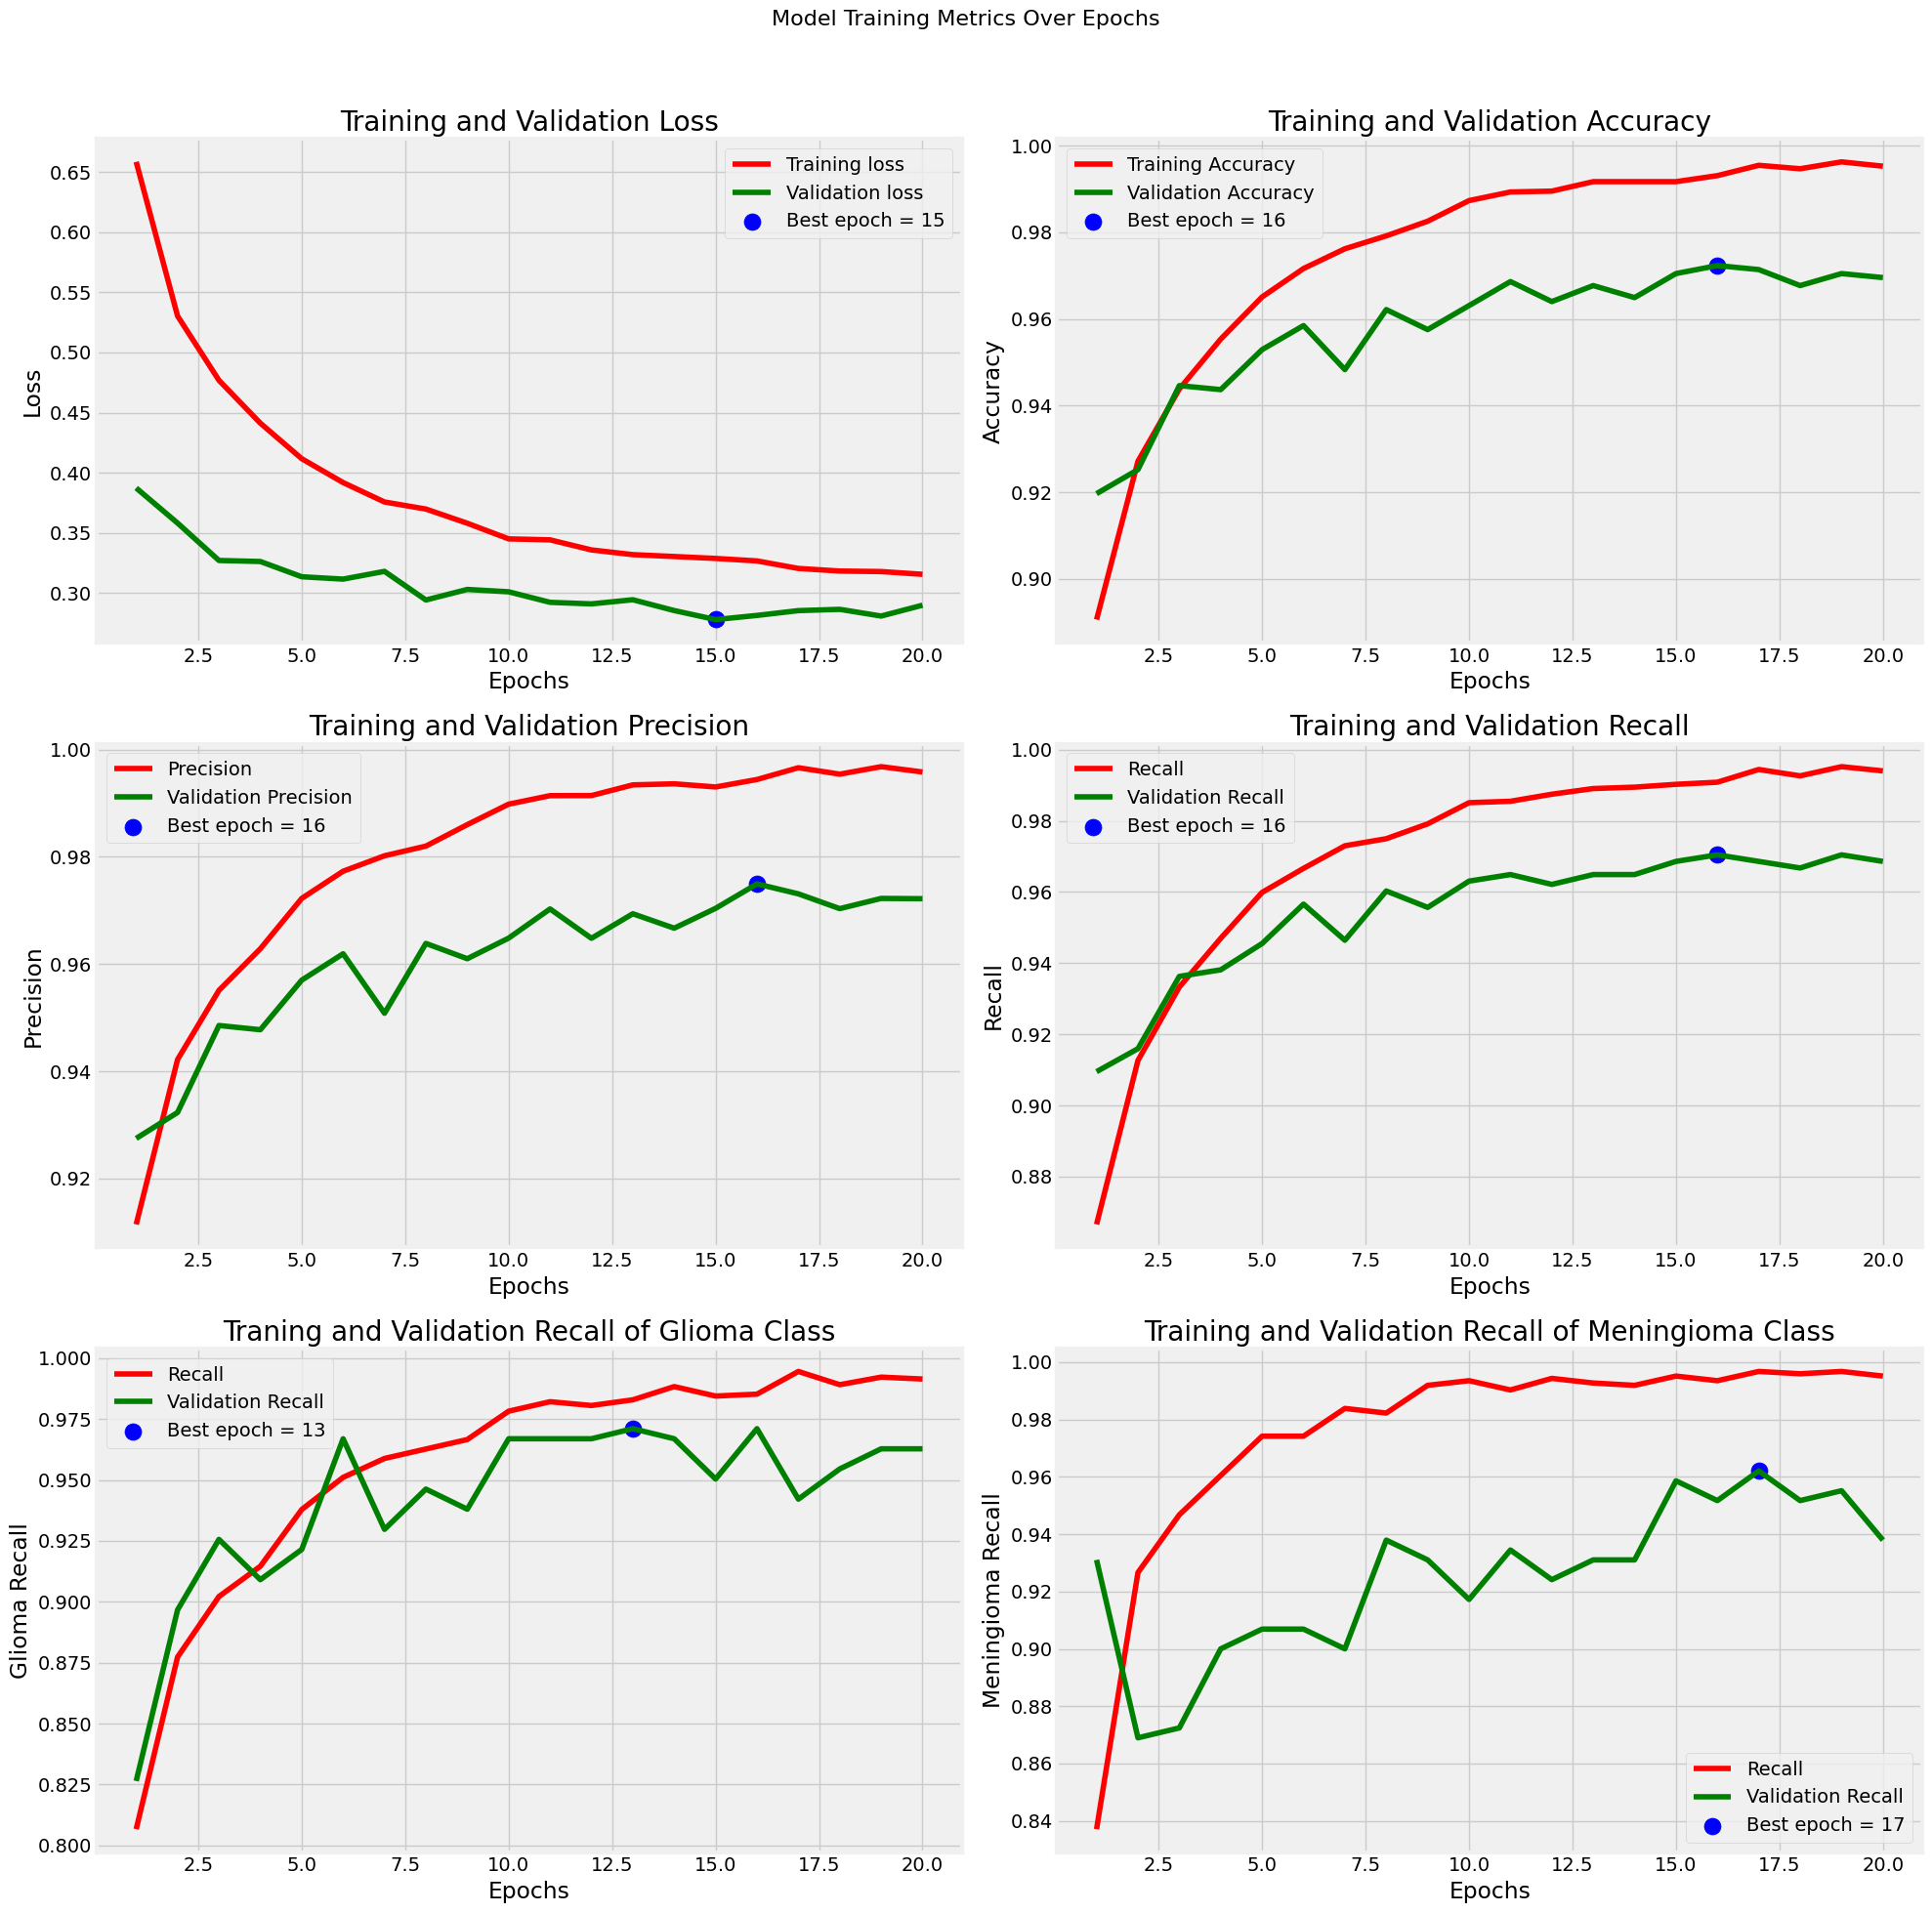

In [20]:
tr_acc = history_fine.history['accuracy_fine']
tr_loss = history_fine.history['loss']
tr_per = history_fine.history['precision_fine']
tr_recall = history_fine.history['recall_fine']
tr_recall_class_0 = history_fine.history['recall_class_0_fine']
tr_recall_class_1 = history_fine.history['recall_class_1_fine']
val_acc = history_fine.history['val_accuracy_fine']
val_loss = history_fine.history['val_loss']
val_per = history_fine.history['val_precision_fine']
val_recall = history_fine.history['val_recall_fine']
val_recall_class_0 = history_fine.history['val_recall_class_0_fine']
val_recall_class_1 = history_fine.history['val_recall_class_1_fine']

def get_best(values, mode='max'):
    if mode == 'max':
        idx = np.argmax(values)
    else:
        idx = np.argmin(values)
    return idx, values[idx]

index_loss, val_lowest = get_best(val_loss, 'min')
index_acc, acc_highest = get_best(val_acc, 'max')
index_precision, per_highest = get_best(val_per, 'max')
index_recall, recall_highest = get_best(val_recall, 'max')
index_recall_class_0, recall_class_0_highest = get_best(val_recall_class_0, 'max')
index_recall_class_1, recall_class_1_highest = get_best(val_recall_class_1, 'max')

Epochs = [i + 1 for i in range(len(tr_acc))]
loss_label = f'Best epoch = {str(index_loss + 1)}'
acc_label = f'Best epoch = {str(index_acc + 1)}'
per_label = f'Best epoch = {str(index_precision + 1)}'
recall_label = f'Best epoch = {str(index_recall + 1)}'
recall_class_0_label = f'Best epoch = {str(index_recall_class_0 + 1)}'
recall_class_1_label = f'Best epoch = {str(index_recall_class_1 + 1)}'


plt.figure(figsize=(20, 20))
plt.style.use('fivethirtyeight')


plt.subplot(3, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label='Training loss')
plt.plot(Epochs, val_loss, 'g', label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 3)
plt.plot(Epochs, tr_per, 'r', label='Precision')
plt.plot(Epochs, val_per, 'g', label='Validation Precision')
plt.scatter(index_precision + 1, per_highest, s=150, c='blue', label=per_label)
plt.title('Training and Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 4)
plt.plot(Epochs, tr_recall, 'r', label='Recall')
plt.plot(Epochs, val_recall, 'g', label='Validation Recall')
plt.scatter(index_recall + 1, recall_highest, s=150, c='blue', label=recall_label)
plt.title('Training and Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 5)
plt.plot(Epochs, tr_recall_class_0, 'r', label='Recall')
plt.plot(Epochs, val_recall_class_0, 'g', label='Validation Recall')
plt.scatter(index_recall_class_0 + 1, recall_class_0_highest, s=150, c='blue', label=recall_class_0_label)
plt.title('Traning and Validation Recall of Glioma Class')
plt.xlabel('Epochs')
plt.ylabel('Glioma Recall')
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 6)
plt.plot(Epochs, tr_recall_class_1, 'r', label='Recall')
plt.plot(Epochs, val_recall_class_1, 'g', label='Validation Recall')
plt.scatter(index_recall_class_1 + 1, recall_class_1_highest, s=150, c='blue', label=recall_class_1_label)
plt.title('Training and Validation Recall of Meningioma Class')
plt.xlabel('Epochs')
plt.ylabel('Meningioma Recall')
plt.legend()
plt.grid(True)

plt.suptitle('Model Training Metrics Over Epochs', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 5. Evaluation

## 5.1 Evaluation Metrics for all sets

In [21]:
train_score = model.evaluate(train_data, verbose=1)
valid_score = model.evaluate(val_data, verbose=1)
test_score = model.evaluate(test_data, verbose=1)

print(f"Train Loss: {train_score[0]:.4f}")
print(f"Train Accuracy: {train_score[1]*100:.2f}%")
print(f"Combined Recall of most difficult classes: {train_score[-1]*100:.2f}%")
print('-' * 20)
print(f"Validation Loss: {valid_score[0]:.4f}")
print(f"Validation Accuracy: {valid_score[1]*100:.2f}%")
print(f"Combined Recall of most difficult classes: {valid_score[-1]*100:.2f}%")
print('-' * 20)
print(f"Test Loss: {test_score[0]:.4f}")
print(f"Test Accuracy: {test_score[1]*100:.2f}%")
print(f"Combined Recall of most difficult classes: {test_score[-1]*100:.2f}%")

158/158 ━━━━━━━━━━━━━━━━━━━━ 84s 189ms/step - accuracy_fine: 0.9966 - loss: 0.2139 - precision_fine: 0.9968 - recall_class_0_fine: 0.9953 - recall_class_1_fine: 0.9952 - recall_class_2_fine: 0.9968 - recall_class_3_fine: 0.9968 - recall_fine: 0.9960 - tumor_recall_fine: 0.9953
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy_fine: 0.9695 - loss: 0.2898 - precision_fine: 0.9722 - recall_class_0_fine: 0.9628 - recall_class_1_fine: 0.9379 - recall_class_2_fine: 0.9774 - recall_class_3_fine: 0.9965 - recall_fine: 0.9686 - tumor_recall_fine: 0.9504
34/34 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy_fine: 0.9787 - loss: 0.2541 - precision_fine: 0.9805 - recall_class_0_fine: 0.9630 - recall_class_1_fine: 0.9667 - recall_class_2_fine: 0.9852 - recall_class_3_fine: 0.9963 - recall_fine: 0.9778 - tumor_recall_fine: 0.9648
Train Loss: 0.2139
Train Accuracy: 99.66%
Combined Recall of most difficult classes: 99.53%
--------------------
Validation Loss: 0.2898
Validation Accuracy: 96.95%
Combined 

## 5.2 Confusion Matrix

34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 465ms/step


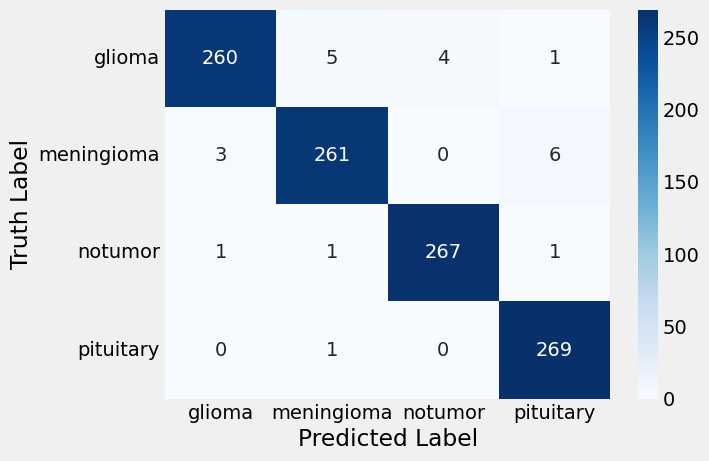

In [22]:
true_labels = np.concatenate([y.numpy() for x, y in test_data], axis=0)
true_labels = np.argmax(true_labels, axis=1)
preds = model.predict(test_data)
y_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(true_labels, y_pred)
labels = class_names
sns.heatmap(
    cm,
    annot=True,
    fmt='d', #forces integer format
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()

## 5.3 Classification Report

In [23]:
clr = classification_report(true_labels, y_pred, target_names=class_names)
print(clr)

              precision    recall  f1-score   support

      glioma       0.98      0.96      0.97       270
  meningioma       0.97      0.97      0.97       270
     notumor       0.99      0.99      0.99       270
   pituitary       0.97      1.00      0.98       270

    accuracy                           0.98      1080
   macro avg       0.98      0.98      0.98      1080
weighted avg       0.98      0.98      0.98      1080

